In [ ]:
!pip install qiskit
!pip install qiskit_aer
!pip install pylatexenc
!pip install qiskit_algorithms

In [ ]:
# Function for plotting quantum circuit
def qplot(x):
  return x.draw('mpl', initial_state = True, fold=False, scale = 0.7)

In [ ]:
import numpy as np
from qiskit import QuantumRegister, QuantumCircuit, ClassicalRegister, transpile
from qiskit.circuit.library import QFT, TGate

from qiskit_aer import QasmSimulator
from qiskit.visualization import plot_histogram

# What is the Problem?
> **Input:**
A quantum circuit implementing an operator $U$, and an eigenstate $|\psi\rangle $ with corresponding eigenvalue $e^{2\pi i\omega}$.

$$U|\psi\rangle = e^{2\pi i\omega} |\psi\rangle$$

> **Problem:** Obtain a good estimate for $\omega$.


### Phase Estimation Approximately

When the phase we want to measure is **not** a power of two $(2^n)$, the phase estimation process becomes **approximate**, with its accuracy depending on the **number of qubits** used in the counting register.

To illustrate this, consider a phase value of:

$$ \theta = \frac{1}{5} $$

Since **Quantum Phase Estimation (QPE)** gives:

$$ U |\psi\rangle = e^{2\pi i \theta} |\psi\rangle $$

we can express the unitary operator $U$ as:

$$ U = \begin{pmatrix} 1 & 0 \\ 0 & e^{\frac{2i\pi}{5}} \end{pmatrix} $$

For the computational basis states, the action of $U$ is:

$$
U |0\rangle = |0\rangle, \qquad U |1\rangle = e^{\frac{2i\pi}{5}} |1\rangle
$$


For doing this I am using qiskit phase gate (`p`) and its controlled-phase gate (`cp`)

$$ P(\alpha) =
 \begin{pmatrix}
  1 & 0 \\
  0 & e^{i\alpha}
  \end{pmatrix} $$


$$ CP(\alpha) =
 \begin{pmatrix}
  1 & 0 & 0 & 0   \\
  0 & 1 & 0 & 0   \\  
  0 & 0 & 1 & 0   \\  
  0 & 0 & 0 & e^{i\alpha} \\
  \end{pmatrix} $$




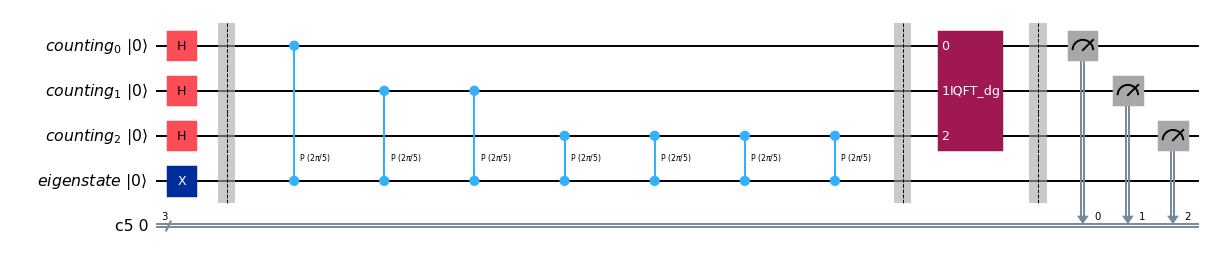

In [ ]:
n = 3
q1 = QuantumRegister(n,name='counting')
q2 = QuantumRegister(1,name = 'eigenstate')
c = ClassicalRegister(n)
qc = QuantumCircuit(q1,q2,c)
qc.x(q2[0])
qc.h(range(n))
qc.barrier()

reps = 1
for i in range(n):
  for j in range(reps):
    qc.cp((2*np.pi)/5, q1[i],q2[0])
  reps *= 2
qc.barrier()


qft_inv = QFT(num_qubits=n, inverse=True)
qc = qc.compose(qft_inv)
qc.barrier()

for i in range(n):
    qc.measure(q1[i],c[i])


qplot(qc)

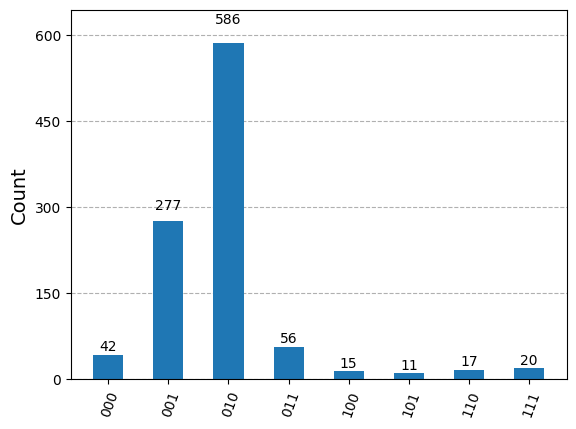

In [ ]:
result = QasmSimulator().run(transpile(qc, QasmSimulator()),shots=1024).result()
count = result.get_counts()
plot_histogram(count)

In [ ]:
print(count)

{'101': 11, '100': 15, '110': 17, '001': 277, '111': 20, '011': 56, '000': 42, '010': 586}


In [ ]:
# Sort the dictionary by measurement counts in descending order
top_three = sorted(count.items(), key=lambda x: x[1], reverse=True)[:3]


result = []
for state, item in top_three:
  result.append(state)
  print(f"State: {state}, Count: {item}")

State: 010, Count: 586
State: 001, Count: 277
State: 011, Count: 56


In [ ]:
# Convert binary outcome to decimal values by 2^n
phase_dec = [int(phase, 2) / 2**n for phase in result]

# Print the phase estimates
print(f"The estimated phase values with highest probability: {phase_dec}, Actual phase value: {1/5}")


The estimated phase values with highest probability: [0.25, 0.125, 0.375], Actual phase value: 0.2


# Solution for improving our phase estimation.
Increasing number of qubit in counting register, we can improve the accuracy of our estimation

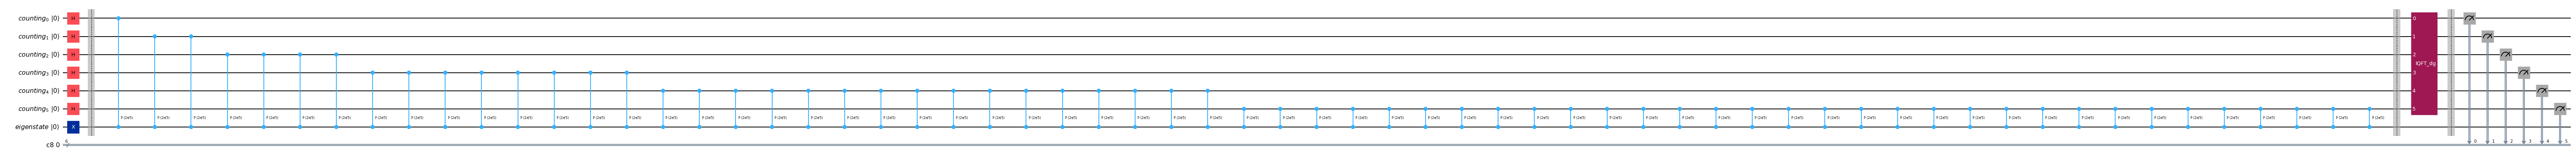

In [ ]:
n = 6
q1 = QuantumRegister(n,name='counting')
q2 = QuantumRegister(1,name = 'eigenstate')
c = ClassicalRegister(n)
qc = QuantumCircuit(q1,q2,c)
qc.x(q2[0])
qc.h(range(n))
qc.barrier()

reps = 1
for i in range(n):
  for j in range(reps):
    qc.cp((2*np.pi)/5, q1[i],q2[0])
  reps *= 2
qc.barrier()


qft_inv = QFT(num_qubits=n, inverse=True)
qc = qc.compose(qft_inv)
qc.barrier()

for i in range(n):
    qc.measure(q1[i],c[i])


qplot(qc)

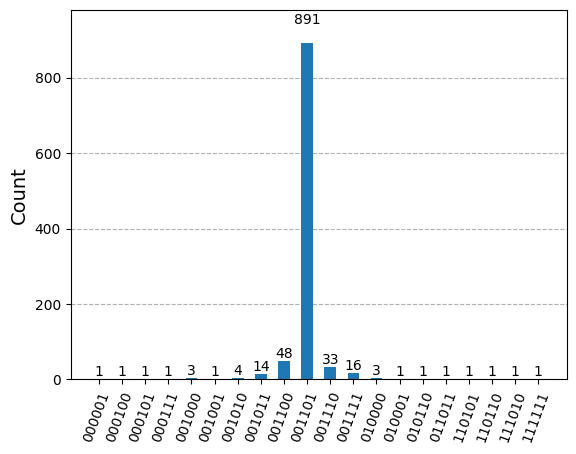

In [ ]:
result = QasmSimulator().run(transpile(qc, QasmSimulator()),shots=1024).result()
count = result.get_counts()
plot_histogram(count)

## Choosing just three outcome which are more probable

In [ ]:
# Sort the dictionary by measurement counts in descending order
top_three = sorted(count.items(), key=lambda x: x[1], reverse=True)[:3]


result = []
for state, item in top_three:
  result.append(state)
  print(f"State: {state}, Count: {item}")

State: 001101, Count: 891
State: 001100, Count: 48
State: 001110, Count: 33


In [ ]:
# Convert binary outcome to decimal values by 2^n
phase_dec = [int(phase, 2) / 2**n for phase in result]

# Print the phase estimates
print(f"The estimated phase values with highest probability: {phase_dec}, Actual phase value: {1/5}")

The estimated phase values with highest probability: [0.203125, 0.1875, 0.21875], Actual phase value: 0.2


By using 6 qubit we have a very close approximation of our phase result!